# Decode Labs Project 2
This notebook uses the built-in Iris dataset. No CSV file is required.


# K Nearest Neighbors Classifier

## Iris Flower Classification

### Step 1: Import Libraries

In [20]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


### Step 2: Load Dataset

In [21]:
from sklearn.datasets import load_iris

data = load_iris(as_frame=True)
df = data.frame.copy()
df["species"] = df["target"].map(dict(enumerate(data.target_names)))
df = df.drop(columns=["target"])
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Step 3: Data Preprocessing & EDA

In [22]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


In [23]:
# Checking Missing values
df.isnull().sum()


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

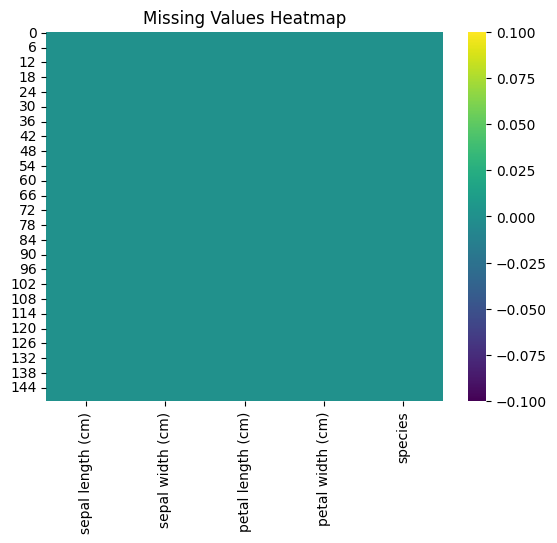

In [24]:
sns.heatmap(df.isnull(), cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


### Step 4: Encoding of Dataset

In [25]:
# Checking string type columns
df.select_dtypes(include="str").columns


Index(['species'], dtype='str')

In [26]:
df["species"].unique()


<ArrowStringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

In [27]:
# Apply Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["species"] = le.fit_transform(df["species"])


In [28]:
df["species"].value_counts()


species
0    50
1    50
2    50
Name: count, dtype: int64

In [29]:
# Class labels: 0 = setosa, 1 = versicolor, 2 = virginica
df["species"].unique()


array([0, 1, 2])

In [30]:
df.head(8)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0


### Step 5: Normalization

In [31]:
# Balance the features for better KNN performance
from sklearn.preprocessing import MinMaxScaler
X_features = df.drop(columns=["species"])
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = pd.DataFrame(scaler.fit_transform(X_features), columns=X_features.columns)
df_scaled = X_scaled.copy()
df_scaled["species"] = df["species"].values


In [32]:
df_scaled.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,0.222222,0.625000,0.067797,0.041667,0
1,0.166667,0.416667,0.067797,0.041667,0
2,0.111111,0.500000,0.050847,0.041667,0
3,0.083333,0.458333,0.084746,0.041667,0
4,0.194444,0.666667,0.067797,0.041667,0


### Visualization

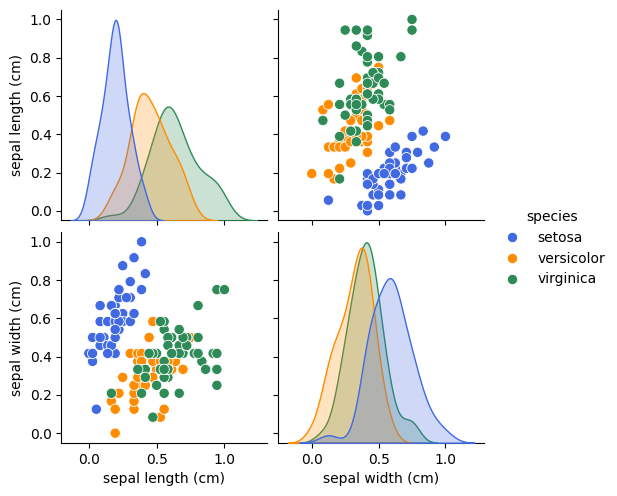

In [33]:
# Pair plot of the Iris flower features
col = df_scaled[["sepal length (cm)", "sepal width (cm)", "species"]].copy()
col["species"] = col["species"].map(dict(enumerate(data.target_names)))
sns.pairplot(data=col, hue="species", palette=["royalblue", "darkorange", "seagreen"], plot_kws={"s": 55})
plt.show()


### Step 6: Splitting of Data into Training & Testing

In [34]:
X = df_scaled.drop(columns=["species"])
y = df_scaled["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 120
Testing samples: 30


### Step 7: Apply Model

In [35]:
# Apply the KNN model
from sklearn.neighbors import KNeighborsClassifier
k = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
k.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Step 8: Prediction

In [36]:
y_pred = k.predict(X_test)
pd.DataFrame({"Actual": y_test, "Predicted": y_pred}).head(15)


,Actual,Predicted
38,0,0
127,2,2
57,1,1
93,1,1
42,0,0
56,1,1
22,0,0
20,0,0
147,2,2
84,1,1


In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)*100
print(f"Accuracy: {accuracy:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Accuracy: 96.67%
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Step 9: Visualization

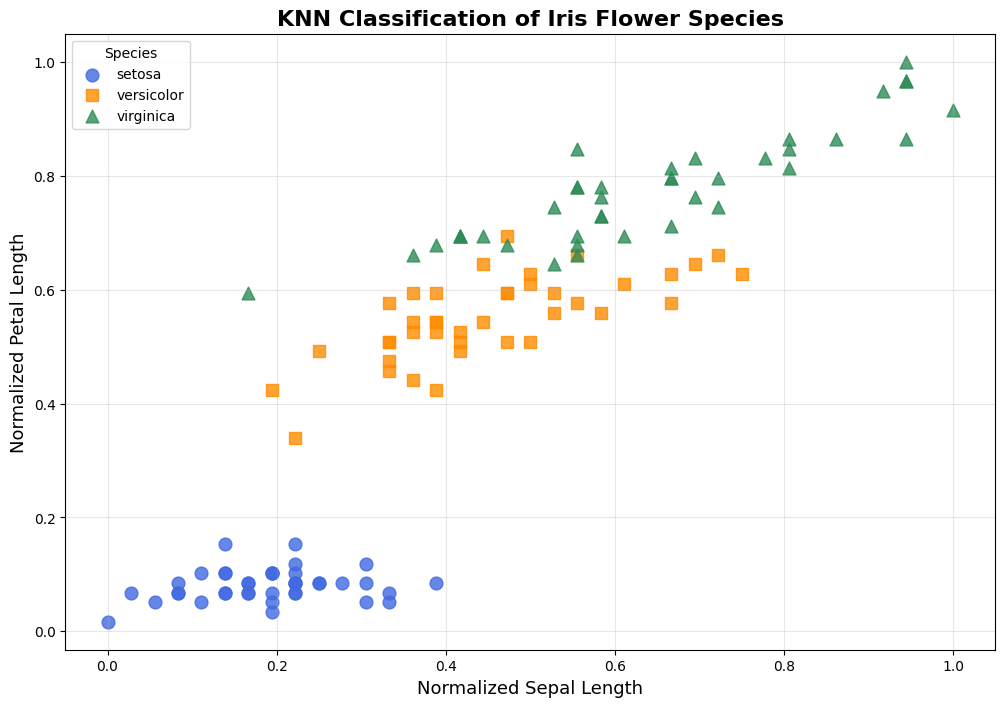

In [38]:
plt.figure(figsize=(12, 8))

# Train a visualization model using two features
X_vis = X_train[["sepal length (cm)", "petal length (cm)"]]
k_vis = KNeighborsClassifier(n_neighbors=5)
k_vis.fit(X_vis, y_train)

for label, marker, color, name in zip([0, 1, 2], ["o", "s", "^"], ["royalblue", "darkorange", "seagreen"], data.target_names):
    mask = y_train == label
    plt.scatter(X_vis.loc[mask, "sepal length (cm)"], X_vis.loc[mask, "petal length (cm)"], marker=marker, color=color, s=85, label=name, alpha=0.8)

plt.title("KNN Classification of Iris Flower Species", fontsize=16, fontweight="bold")
plt.xlabel("Normalized Sepal Length", fontsize=13)
plt.ylabel("Normalized Petal Length", fontsize=13)
plt.legend(title="Species")
plt.grid(alpha=0.3)
plt.show()


## Conclusion
The K Nearest Neighbors classifier successfully learned patterns from the Iris flower measurements and classified unseen flowers into setosa, versicolor, and virginica species. Feature normalization was applied because KNN uses distance calculations. The train-test split, prediction table, accuracy score, and classification report provide a complete supervised learning workflow for DecodeLabs Project 2: Data Classification Using AI.

This project demonstrates dataset loading, preprocessing, label encoding, normalization, model training, prediction, evaluation, and visualization using a simple AI classification algorithm.